In [29]:
# Cell 1: Install Required Libraries
!pip install geemap earthengine-api geopandas rasterio scikit-learn -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
# Cell 2: Import Required Libraries
import ee
import geemap
import json
import geopandas as gpd
import rasterio

In [31]:
# Cell 3: Authenticate Google Earth Engine
ee.Authenticate()

True

In [32]:
# Cell 4: Initialize Google Earth Engine
PROJECT = "seagrass-uae-project"

ee.Initialize(project=PROJECT)

print(" Earth Engine initialized successfully!")

 Earth Engine initialized successfully!


In [33]:

# Cell 5: Load Study Area from Uploaded GeoJSON
import json
import os

# Works both in Colab (uploaded to /content/) and running locally in this repo.
_study_area_candidates = [
    "/content/study_area.geojson",
    "../data/study_area/study_area.geojson",  # repo-relative, running from M2_classification/
    "data/study_area/study_area.geojson",     # repo-relative, running from repo root
    "study_area.geojson",                     # same folder as the notebook
]
study_area_path = next((p for p in _study_area_candidates if os.path.exists(p)), None)
if study_area_path is None:
    raise FileNotFoundError(
        f"study_area.geojson not found in any of: {_study_area_candidates}"
    )

with open(study_area_path) as f:
    geojson = json.load(f)

study_area = ee.Geometry(geojson["features"][0]["geometry"])

print(f" Study area loaded successfully from {study_area_path}!")

 Study area loaded successfully from ../data/study_area/study_area.geojson!


In [34]:
# Cell 6: Display Study Area
Map = geemap.Map()

Map.centerObject(study_area, 10)

Map.addLayer(
    study_area,
    {"color": "red"},
    "Study Area"
)

Map

Map(center=[24.33124301479575, 53.149610427080574], controls=(WidgetControl(options=['position', 'transparent_…

In [35]:
# Cell 7: Load Sentinel-2 Surface Reflectance Collection
start_date = "2024-01-01"
end_date   = "2024-12-31"

sentinel2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
      .filterBounds(study_area)
      .filterDate(start_date, end_date)
      .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
)

print("Number of images:", sentinel2.size().getInfo())

Number of images: 222


In [36]:
# Cell 8: Create Median Composite Image
composite = sentinel2.median().clip(study_area)

print("Composite image created successfully!")

Composite image created successfully!


In [37]:
# Cell 9: Display Sentinel-2 Composite
rgb_vis = {
    "bands": ["B4", "B3", "B2"],
    "min": 0,
    "max": 3000
}

Map = geemap.Map()

Map.centerObject(study_area, 11)

Map.addLayer(composite, rgb_vis, "Sentinel-2 RGB")

Map.addLayer(
    study_area,
    {"color": "red"},
    "Study Area"
)

Map

Map(center=[24.331243014795326, 53.149610427080006], controls=(WidgetControl(options=['position', 'transparent…

In [38]:

# Cell 9 optional: Display Sentinel-2 Composite


rgb_vis = {
    "bands": ["B4", "B3", "B2"],
    "min": 0,
    "max": 3000
}

Map = geemap.Map()

# Use a satellite basemap
Map.add_basemap("SATELLITE")

Map.centerObject(study_area, 11)

Map.addLayer(
    composite,
    rgb_vis,
    "Sentinel-2 RGB"
)

Map.addLayer(
    study_area,
    {"color": "red"},
    "Study Area"
)

Map

Map(center=[24.331243014795326, 53.149610427080006], controls=(WidgetControl(options=['position', 'transparent…

In [39]:
# Cell 10: Define Sentinel-2 Cloud Mask Function
def mask_s2_clouds(image):
    """
    Masks clouds and cirrus using the QA60 band.
    """
    qa = image.select("QA60")

    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    mask = (
        qa.bitwiseAnd(cloud_bit_mask).eq(0)
        .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    )

    return (
        image.updateMask(mask)
             .divide(10000)
             .copyProperties(image, ["system:time_start"])
    )

In [40]:
# Cell 11: Apply Cloud Mask and Create Clean Composite
clean_collection = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(study_area)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
        .map(mask_s2_clouds)
)

clean_composite = clean_collection.median().clip(study_area)

print(" Cloud-free composite created successfully!")

 Cloud-free composite created successfully!


In [41]:
# Cell 12: Display Cloud-Free Sentinel-2 Composite
rgb_vis = {
    "bands": ["B4", "B3", "B2"],
    "min": 0.0,
    "max": 0.30
}

Map = geemap.Map()

Map.add_basemap("SATELLITE")

Map.centerObject(study_area, 11)

Map.addLayer(
    clean_composite,
    rgb_vis,
    "Cloud-Free Sentinel-2"
)

Map.addLayer(
    study_area,
    {"color": "red"},
    "Study Area"
)

Map

Map(center=[24.331243014795326, 53.149610427080006], controls=(WidgetControl(options=['position', 'transparent…

In [42]:
# Cell 13: Calculate NDVI (Normalized Difference Vegetation Index)
ndvi = clean_composite.normalizedDifference(
    ["B8", "B4"]
).rename("NDVI")

print(" NDVI created successfully!")

 NDVI created successfully!


In [43]:
# Cell 14: Display NDVI
ndvi_vis = {
    "min": -1,
    "max": 1,
    "palette": ["blue", "white", "green"]
}

# Create the interactive map
Map = geemap.Map()

Map.add_basemap("SATELLITE")

Map.centerObject(study_area, 11)

# Add NDVI layer
Map.addLayer(
    ndvi,
    ndvi_vis,
    "NDVI"
)
# Add study area boundary, only some of them cover the picture
outline = ee.Image().byte().paint(
    featureCollection=study_area,
    color=1,
    width=2
)
# Add study area
Map.addLayer(
    study_area,
    {"color": "red"},
    "Study Area"
)

# Enable layer control
Map.addLayerControl()

Map

Map(center=[24.331243014795326, 53.149610427080006], controls=(WidgetControl(options=['position', 'transparent…

In [44]:
# Cell 15: Calculate NDWI (Normalized Difference Water Index)
ndwi = clean_composite.normalizedDifference(
    ["B3", "B8"]
).rename("NDWI")

print(" NDWI created successfully!")

 NDWI created successfully!


In [45]:
# ============================================================
# Cell 16: Add NDWI Layer
# ============================================================

ndwi_vis = {
    "min": -1,
    "max": 1,
    "palette": ["brown", "white", "blue"]
}

Map.addLayer(
    ndwi,
    ndwi_vis,
    "NDWI"
)

Map

Map(center=[24.331243014795326, 53.149610427080006], controls=(WidgetControl(options=['position', 'transparent…

In [46]:
# Cell 17: Calculate Modified NDWI (MNDWI)
mndwi = clean_composite.normalizedDifference(
    ["B3", "B11"]
).rename("MNDWI")

print(" MNDWI created successfully!")

 MNDWI created successfully!


In [47]:
# Cell 18: Add MNDWI Layer
# ============================================================

mndwi_vis = {
    "min": -1,
    "max": 1,
    "palette": ["brown", "white", "cyan"]
}

Map.addLayer(
    mndwi,
    mndwi_vis,
    "MNDWI"
)

Map

Map(bottom=225893.0, center=[24.331243014795326, 53.149610427080006], controls=(WidgetControl(options=['positi…

In [48]:
# Cell 19: Calculate Bare Soil Index (BSI)
bsi = clean_composite.expression(
    "((SWIR + RED) - (NIR + BLUE)) / ((SWIR + RED) + (NIR + BLUE))",
    {
        "SWIR": clean_composite.select("B11"),
        "RED": clean_composite.select("B4"),
        "NIR": clean_composite.select("B8"),
        "BLUE": clean_composite.select("B2")
    }
).rename("BSI")

print(" BSI created successfully!")

 BSI created successfully!


In [49]:
# Cell 20: Display Bare Soil Index (BSI)
bsi_vis = {
    "min": -1,
    "max": 1,
    "palette": [
        "blue",
        "white",
        "brown"
    ]
}

Map = geemap.Map()

Map.centerObject(study_area, 11)

Map.addLayer(
    bsi,
    bsi_vis,
    "BSI"
)

Map.addLayer(
    study_area,
    {"color": "red"},
    "Study Area"
)

Map

Map(center=[24.331243014795326, 53.149610427080006], controls=(WidgetControl(options=['position', 'transparent…

In [50]:
# Cell 21: Build Feature Stack
feature_stack = clean_composite.addBands([
    ndvi,
    ndwi,
    mndwi,
    bsi
])

print(" Feature stack created successfully!")

 Feature stack created successfully!


In [51]:
# Cell 22: Check Feature Stack Bands
print(feature_stack.bandNames().getInfo())


['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE', 'NDVI', 'NDWI', 'MNDWI', 'BSI']


In [52]:
# Cell 23: Display Feature Stack (RGB)
rgb_vis = {
    "bands": ["B4", "B3", "B2"],
    "min": 0,
    "max": 0.30
}

Map = geemap.Map()

Map.centerObject(study_area, 11)

Map.addLayer(
    feature_stack,
    rgb_vis,
    "Feature Stack RGB"
)

Map.addLayer(
    study_area,
    {"color": "red"},
    "Study Area"
)

Map.addLayerControl()

Map

Map(center=[24.331243014795326, 53.149610427080006], controls=(WidgetControl(options=['position', 'transparent…

In [53]:
# A7: Acquire Official EAD Seagrass Habitat Reference Data

In [54]:
# Connect to the Environment Agency – Abu Dhabi (EAD) Habitat Service

# This section retrieves the official seagrass habitat reference data from the Environment Agency – Abu Dhabi (EAD).
 # These reference polygons will be used to generate training samples for supervised Random Forest classification.

In [55]:
# Cell 24: Import Libraries for EAD Habitat Data
import requests
import geopandas as gpd

In [56]:
# Cell 25: Define the EAD Marine Habitat Service
ead_url = (
    "https://arcgis.sdi.abudhabi.ae/agspublish/rest/services/"
    "OpenData/ADSDI_OpenData/MapServer/141/query"
)

print(" EAD Marine Habitat service defined.")

 EAD Marine Habitat service defined.


In [57]:
# Cell 26: Download Seagrass Habitat Polygons
params = {
    "where": "HABITATTYPE='Seagrass bed'",
    "outFields": "*",
    "returnGeometry": "true",
    "f": "geojson"
}

response = requests.get(ead_url, params=params)

print(response.status_code)

200


In [58]:
# Cell 27: Save Seagrass Habitat GeoJSON
with open("ead_seagrass.geojson", "w", encoding="utf-8") as f:
    f.write(response.text)

print(" GeoJSON saved successfully!")

 GeoJSON saved successfully!


In [59]:
# Cell 28: Load Official EAD Seagrass Data
ead_seagrass = gpd.read_file("ead_seagrass.geojson")

print("Total EAD seagrass polygons:", len(ead_seagrass))

ead_seagrass.head()

Total EAD seagrass polygons: 1954


,OBJECTID,HABITATTYPENO,HABITATTYPE,HABITATSUBTYPENO,HABITATSUBTYPE,AREA_KM,AREA_HA,ID,MMU_HA,GLOBALID,CH_FID,RULEID_3,OVERRIDE_1,SHAPE.STArea(),SHAPE.STLength(),geometry
0,150871,12000,Seagrass bed,12000,Seagrass bed,0.008854,0.885408,89392,0,{49167D4F-7AD5-42A5-930C-48BF79E32108},EAD_14_7_2022_6084#279#3366,47,None,7.854630e-07,0.004006,"POLYGON ((52.1504 23.97052, 52.1503 23.97034, ..."
1,150872,12000,Seagrass bed,12000,Seagrass bed,0.011005,1.100512,89393,0,{C2F7F076-A1B2-4F1E-A495-888247B03DFB},EAD_14_7_2022_6084#279#3367,47,None,9.762831e-07,0.005776,"POLYGON ((52.14763 23.96882, 52.14714 23.96928..."
2,150873,12000,Seagrass bed,12000,Seagrass bed,0.007704,0.770353,89394,0,{43102056-337B-45E2-8AA2-E6FD6AC8D0DD},EAD_14_7_2022_6084#279#3368,47,None,6.833983e-07,0.003132,"POLYGON ((52.15678 23.97011, 52.15678 23.97047..."
3,150874,12000,Seagrass bed,12000,Seagrass bed,0.066881,6.688053,89395,0,{BFEFCCAD-9D49-499E-9350-EADEECB6C2EC},EAD_14_7_2022_6084#279#3369,47,None,5.933087e-06,0.016636,"POLYGON ((52.15855 23.97001, 52.15846 23.97073..."
4,150875,12000,Seagrass bed,12000,Seagrass bed,0.019409,1.940903,89396,0,{633B3C52-500A-4A35-82CC-062AED06B306},EAD_14_7_2022_6084#279#3370,47,None,1.721826e-06,0.009258,"POLYGON ((52.14284 23.97202, 52.14274 23.97148..."


In [62]:
# Cell 29: Load Study Area GeoJSON
# Reuses study_area_path resolved back in Cell 5 (works in both Colab and locally).
study_area_gdf = gpd.read_file(study_area_path)

print(study_area_gdf.crs)
study_area_gdf.head()

EPSG:4326


,name,geometry
0,Marawah_Study_Area,"POLYGON ((53.27 24.38, 53.2 24.47, 53.1 24.48,..."


In [63]:
# Cell 30: Verify Coordinate Reference Systems (CRS)
print("Study Area CRS :", study_area_gdf.crs)
print("EAD Seagrass CRS:", ead_seagrass.crs)

# Reproject only if necessary
if study_area_gdf.crs != ead_seagrass.crs:
    ead_seagrass = ead_seagrass.to_crs(study_area_gdf.crs)
    print(" CRS matched.")
else:
    print(" Both datasets already use the same CRS.")

Study Area CRS : EPSG:4326
EAD Seagrass CRS: EPSG:4326
 Both datasets already use the same CRS.


In [64]:
# Cell 31: Clip Official EAD Seagrass to Study Area
ead_marawah = gpd.clip(ead_seagrass, study_area_gdf)

print("Official EAD seagrass polygons inside study area:", len(ead_marawah))

Official EAD seagrass polygons inside study area: 118


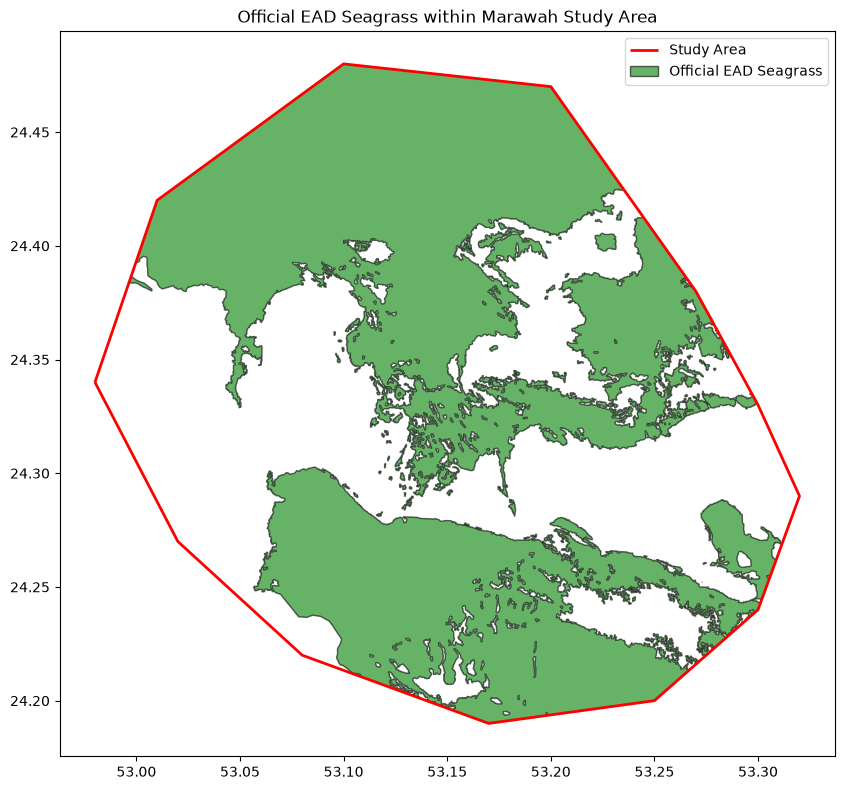

In [65]:
# Cell 32: Plot Clipped Seagrass Polygons
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

study_area_gdf.boundary.plot(
    ax=ax,
    color="red",
    linewidth=2,
    label="Study Area"
)

ead_marawah.plot(
    ax=ax,
    color="green",
    alpha=0.6,
    edgecolor="black",
    label="Official EAD Seagrass"
)

plt.title("Official EAD Seagrass within Marawah Study Area")
plt.legend()

plt.show()

In [66]:
# Cell 33: Save Clipped EAD Seagrass Reference Data
ead_marawah.to_file(
    "marawah_ead_seagrass_reference.geojson",
    driver="GeoJSON"
)

print(" Saved:", "marawah_ead_seagrass_reference.geojson")

 Saved: marawah_ead_seagrass_reference.geojson


In [69]:
#A8 – Prepare the Random Forest Training Dataset

In [68]:
# Cell 34: Download Official Non-Seagrass Habitat
import requests

params = {
    "where": "HABITATTYPE = 'Unconsolidated bottom'",
    "outFields": "*",
    "returnGeometry": "true",
    "f": "geojson"
}

response = requests.get(ead_url, params=params)

print("HTTP Status:", response.status_code)

with open("ead_non_seagrass.geojson", "w") as f:
    f.write(response.text)

print(" Official non-seagrass habitat downloaded.")

HTTP Status: 200
 Official non-seagrass habitat downloaded.


In [70]:
# Cell 35: Load Official Non-Seagrass Habitat
non_seagrass = gpd.read_file("ead_non_seagrass.geojson")

print("Total official non-seagrass polygons:", len(non_seagrass))

non_seagrass.head()

Total official non-seagrass polygons: 2000


,OBJECTID,HABITATTYPENO,HABITATTYPE,HABITATSUBTYPENO,HABITATSUBTYPE,AREA_KM,AREA_HA,ID,MMU_HA,GLOBALID,CH_FID,RULEID_3,OVERRIDE_1,SHAPE.STArea(),SHAPE.STLength(),geometry
0,157510,14000,Unconsolidated bottom,14000,Unconsolidated Bottom,0.002030,0.202950,96031,0,{90199260-4379-4323-B801-073CFA52D02A},EAD_14_7_2022_6084#279#10005,50,None,1.800378e-07,0.002436,"POLYGON ((52.21258 23.96751, 52.21238 23.96751..."
1,157511,14000,Unconsolidated bottom,14000,Unconsolidated Bottom,0.018007,1.800745,96032,0,{52D40AC5-CDE1-43CC-87F6-7F956162C4C5},EAD_14_7_2022_6084#279#10006,50,None,1.597562e-06,0.005910,"POLYGON ((52.22928 23.97749, 52.22918 23.97704..."
2,157512,14000,Unconsolidated bottom,14000,Unconsolidated Bottom,0.008303,0.830340,96033,0,{DB68EDF2-CA09-4697-BB85-9D2C5A83B61D},EAD_14_7_2022_6084#279#10007,50,None,7.366525e-07,0.003606,"POLYGON ((52.23449 23.97709, 52.2343 23.97736,..."
3,157513,14000,Unconsolidated bottom,14000,Unconsolidated Bottom,0.071433,7.143261,96034,0,{8AD3F18F-C7F1-4820-BBF0-FAD8F3627FB5},EAD_14_7_2022_6084#279#10008,50,None,6.337381e-06,0.020434,"POLYGON ((52.16306 23.98027, 52.16277 23.98027..."
4,157514,14000,Unconsolidated bottom,14000,Unconsolidated Bottom,0.025360,2.536047,96035,0,{A0B0ED3B-DC36-47C5-97AC-AB0D4553D76C},EAD_14_7_2022_6084#279#10009,50,None,2.249927e-06,0.009655,"POLYGON ((52.23059 23.98019, 52.23029 23.98019..."


In [71]:
# Cell 36: Clip Non-Seagrass Habitat to the Study Area
# Clip official unconsolidated bottom polygons
non_seagrass_marawah = gpd.clip(non_seagrass, study_area_gdf)

print("Official non-seagrass polygons inside study area:",
      len(non_seagrass_marawah))

non_seagrass_marawah.head()

Official non-seagrass polygons inside study area: 171


,OBJECTID,HABITATTYPENO,HABITATTYPE,HABITATSUBTYPENO,HABITATSUBTYPE,AREA_KM,AREA_HA,ID,MMU_HA,GLOBALID,CH_FID,RULEID_3,OVERRIDE_1,SHAPE.STArea(),SHAPE.STLength(),geometry
1538,159048,14000,Unconsolidated bottom,14000,Unconsolidated Bottom,61.250199,6125.019914,97569,0,{67E3B828-42FF-4EDD-ACAD-29AA9129C3ED},EAD_14_7_2022_6084#279#11543,50,None,0.005445,2.773965,"MULTIPOLYGON (((53.04562 24.24866, 53.04582 24..."
1151,158661,14000,Unconsolidated bottom,14000,Unconsolidated Bottom,0.548556,54.855601,97182,0,{F70CA5FA-84F4-48B7-86EE-BBA61A04FB41},EAD_14_7_2022_6084#279#11156,50,None,0.000049,0.106291,"POLYGON ((53.28412 24.22784, 53.28392 24.2282,..."
958,158468,14000,Unconsolidated bottom,14000,Unconsolidated Bottom,0.033738,3.373848,96989,0,{C3331F06-150F-452D-AA9D-59E49B8A2A41},EAD_14_7_2022_6084#279#10963,50,None,0.000003,0.006944,"POLYGON ((53.11773 24.2149, 53.11655 24.21492,..."
977,158487,14000,Unconsolidated bottom,14000,Unconsolidated Bottom,0.015544,1.554426,97008,0,{9D0BFBFB-B43A-4BCC-BB8F-84804FA2B6B1},EAD_14_7_2022_6084#279#10982,50,None,0.000001,0.005247,"POLYGON ((53.14279 24.21843, 53.14298 24.21825..."
980,158490,14000,Unconsolidated bottom,14000,Unconsolidated Bottom,0.014795,1.479501,97011,0,{B9A4A715-AB2C-42D2-BABD-5BA8B799773B},EAD_14_7_2022_6084#279#10985,50,None,0.000001,0.004956,"POLYGON ((53.11358 24.21992, 53.11427 24.21991..."


In [72]:
# Cell 37: Assign Training Class Labels
# Seagrass = 1
ead_marawah["class"] = 1

# Non-seagrass = 0
non_seagrass_marawah["class"] = 0

print("Seagrass class assigned.")
print("Non-seagrass class assigned.")

# Check the new column
print("\nSeagrass:")
print(ead_marawah[["HABITATTYPE", "class"]].head())

print("\nNon-Seagrass:")
print(non_seagrass_marawah[["HABITATTYPE", "class"]].head())

Seagrass class assigned.
Non-seagrass class assigned.

Seagrass:
      HABITATTYPE  class
596  Seagrass bed      1
613  Seagrass bed      1
614  Seagrass bed      1
625  Seagrass bed      1
648  Seagrass bed      1

Non-Seagrass:
                HABITATTYPE  class
1538  Unconsolidated bottom      0
1151  Unconsolidated bottom      0
958   Unconsolidated bottom      0
977   Unconsolidated bottom      0
980   Unconsolidated bottom      0


In [73]:
# Cell 38: Save Prepared Training Classes
ead_marawah.to_file(
    "marawah_seagrass_training.geojson",
    driver="GeoJSON"
)

non_seagrass_marawah.to_file(
    "marawah_non_seagrass_training.geojson",
    driver="GeoJSON"
)

print(" Training datasets saved.")
print("Seagrass polygons:", len(ead_marawah))
print("Non-seagrass polygons:", len(non_seagrass_marawah))

 Training datasets saved.
Seagrass polygons: 118
Non-seagrass polygons: 171


In [74]:
# Module A9: Random Forest Classification (Original Dataset)


In [75]:
# Cell 40: Merge Original Training Dataset
import pandas as pd

# Merge seagrass and non-seagrass polygons
training_gdf = pd.concat(
    [ead_marawah, non_seagrass_marawah],
    ignore_index=True
)

print("===================================")
print("Original Training Dataset")
print("===================================")
print(f"Total polygons: {len(training_gdf)}")
print()

print(training_gdf["class"].value_counts())

Original Training Dataset
Total polygons: 289

class
0    171
1    118
Name: count, dtype: int64


In [76]:
# ============================================================
# Cell 41: Convert Training Data to Earth Engine
# ============================================================

import json
import ee

# Keep only the required columns
ead_clean = ead_marawah[["class", "geometry"]].copy()
non_clean = non_seagrass_marawah[["class", "geometry"]].copy()

# Convert to GeoJSON dictionaries
seagrass_geojson = json.loads(ead_clean.to_json())
non_seagrass_geojson = json.loads(non_clean.to_json())

# Convert to Earth Engine FeatureCollections
ee_seagrass = ee.FeatureCollection(seagrass_geojson)
ee_non_seagrass = ee.FeatureCollection(non_seagrass_geojson)

# Merge classes
ee_training = ee_seagrass.merge(ee_non_seagrass)

print("Earth Engine training dataset created.")
print("Training features:", ee_training.size().getInfo())

Earth Engine training dataset created.
Training features: 289


In [77]:
# Cell 42: Create Predictor Image
# Predictor bands for Random Forest
predictor_bands = [
    "B2", "B3", "B4",
    "B5", "B6", "B7",
    "B8", "B8A",
    "B11", "B12",
    "NDVI",
    "NDWI",
    "MNDWI",
    "BSI"
]

# Keep only predictor bands
predictor_image = feature_stack.select(predictor_bands)

print("Predictor image created successfully.")
print("Predictor bands:")
print(predictor_image.bandNames().getInfo())

Predictor image created successfully.
Predictor bands:
['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'MNDWI', 'BSI']


In [78]:
# ============================================================
# Cell 43: Generate Random Training Points
# ============================================================

# Number of points for each class
SEAGRASS_POINTS = 500
NON_SEAGRASS_POINTS = 500

# Generate random points inside seagrass polygons
seagrass_points = ee.FeatureCollection.randomPoints(
    region=ee_seagrass.geometry(),
    points=SEAGRASS_POINTS,
    seed=42
).map(lambda f: f.set("class", 1))

# Generate random points inside non-seagrass polygons
non_seagrass_points = ee.FeatureCollection.randomPoints(
    region=ee_non_seagrass.geometry(),
    points=NON_SEAGRASS_POINTS,
    seed=42
).map(lambda f: f.set("class", 0))

# Merge both classes
training_points = seagrass_points.merge(non_seagrass_points)

print("Training points created.")
print(training_points.size().getInfo())

Training points created.
1000


In [79]:
# ============================================================
# Cell 44: Sample Predictor Values
# ============================================================

training_samples = predictor_image.sampleRegions(
    collection=training_points,
    properties=["class"],
    scale=10,
    geometries=False
)

print("Training samples extracted successfully.")
print("Number of samples:", training_samples.size().getInfo())

# Display the first sample
print(training_samples.first().getInfo())

Training samples extracted successfully.
Number of samples: 1000


KeyboardInterrupt: 

In [ ]:
# ============================================================
# Cell 45: Split Training and Testing Data
# ============================================================

# Add a random number to each sample
samples = training_samples.randomColumn("random", seed=42)

# 80% for training
training_set = samples.filter(ee.Filter.lt("random", 0.8))

# 20% for testing
testing_set = samples.filter(ee.Filter.gte("random", 0.8))

print("Training samples:", training_set.size().getInfo())
print("Testing samples :", testing_set.size().getInfo())

In [ ]:
# ============================================================
# Cell 46: Train Random Forest Classifier
# ============================================================

# Train the Random Forest classifier
rf_classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=100,
    seed=42
).train(
    features=training_set,
    classProperty="class",
    inputProperties=predictor_bands
)

print("Random Forest classifier trained successfully.")

In [ ]:
# ============================================================
# Cell 47: Classify Predictor Image
# ============================================================

# Apply the trained Random Forest classifier
classified_image = predictor_image.classify(rf_classifier)

print("Image classified successfully.")

In [ ]:
# ============================================================
# Cell 48: Classify Testing Samples
# ============================================================

# Predict the class of the testing samples
classified_test = testing_set.classify(rf_classifier)

print("Testing samples classified successfully.")
print("Testing samples:", classified_test.size().getInfo())

In [ ]:
# ============================================================
# Cell 49: Display Classification Map
# ============================================================

# Visualization parameters
classification_vis = {
    "min": 0,
    "max": 1,
    "palette": [
        "brown",      # 0 = Non-seagrass
        "limegreen"   # 1 = Seagrass
    ]
}

# Create interactive map
import geemap
Map = geemap.Map()

Map.add_basemap("SATELLITE")

# Center on study area
Map.centerObject(study_area, 11)

# Add classified image
Map.addLayer(
    classified_image,
    classification_vis,
    "Random Forest Classification"
)

# Add study area boundary
outline = ee.Image().byte().paint(
    featureCollection=study_area,
    color=1,
    width=2
)

Map.addLayer(
    outline,
    {"palette": ["red"]},
    "Study Area"
)

Map

In [ ]:
# ============================================================
# Cell 50: Accuracy Assessment
# ============================================================

# Compute confusion matrix
confusion_matrix = classified_test.errorMatrix(
    "class",
    "classification"
)

print("Confusion Matrix")
print(confusion_matrix.getInfo())

print("\nOverall Accuracy:")
print(confusion_matrix.accuracy().getInfo())

print("\nKappa Coefficient:")
print(confusion_matrix.kappa().getInfo())

print("\nProducer's Accuracy:")
print(confusion_matrix.producersAccuracy().getInfo())

print("\nUser's Accuracy:")
print(confusion_matrix.consumersAccuracy().getInfo())

In [ ]:
# Original Confusion Matrix
import pandas as pd

original_cm = pd.DataFrame(
    confusion_matrix.getInfo(),
    index=["Actual Non-Seagrass", "Actual Seagrass"],
    columns=["Predicted Non-Seagrass", "Predicted Seagrass"]
)

print("Original Confusion Matrix\n")
display(original_cm)

In [ ]:
# Cell 51: Random Forest Classification Summary
print("=" * 65)
print("      RANDOM FOREST CLASSIFICATION SUMMARY")
print("=" * 65)

print("\nTraining Dataset")
print("-" * 30)
print(f"Training Samples : {training_set.size().getInfo()}")
print(f"Testing Samples  : {testing_set.size().getInfo()}")

print("\nModel Parameters")
print("-" * 30)
print("Algorithm        : Random Forest")
print("Decision Trees   : 100")
print("Predictor Bands  : 14")
print("Random Seed      : 42")

print("\nClassification Accuracy")
print("-" * 30)
print(f"Overall Accuracy : {confusion_matrix.accuracy().getInfo()*100:.2f}%")
print(f"Kappa Coefficient: {confusion_matrix.kappa().getInfo():.3f}")

print("\nProducer's Accuracy")
print("-" * 30)
pa = confusion_matrix.producersAccuracy().getInfo()
print(f"Non-Seagrass     : {pa[0][0]*100:.2f}%")
print(f"Seagrass         : {pa[1][0]*100:.2f}%")

print("\nUser's Accuracy")
print("-" * 30)
ua = confusion_matrix.consumersAccuracy().getInfo()
print(f"Non-Seagrass     : {ua[0][0]*100:.2f}%")
print(f"Seagrass         : {ua[0][1]*100:.2f}%")

print("\nStatus")
print("-" * 30)
print("✓ Random Forest model trained successfully")
print("✓ Classification completed")
print("✓ Accuracy assessment completed")
print("✓ Baseline model ready for comparison")

print("=" * 65)

In [ ]:
#A10: Balanced Random Forest Classification

In [ ]:
# Cell 52: Create Balanced Training Dataset

import pandas as pd

# Number of seagrass polygons
n_seagrass = len(ead_marawah)

# Randomly select the same number of non-seagrass polygons
balanced_non_seagrass = non_seagrass_marawah.sample(
    n=n_seagrass,
    random_state=42
)

# Merge into one balanced dataset
balanced_training_gdf = pd.concat(
    [ead_marawah, balanced_non_seagrass],
    ignore_index=True
)

print("Balanced training dataset created.\n")
print(f"Seagrass polygons     : {len(ead_marawah)}")
print(f"Non-seagrass polygons : {len(balanced_non_seagrass)}")
print(f"Total polygons        : {len(balanced_training_gdf)}")

print("\n✓ Ready for Earth Engine.")

In [ ]:
# Cell 53: Convert Balanced Dataset to Earth Engine
import json

# Separate classes
balanced_seagrass = balanced_training_gdf[
    balanced_training_gdf["class"] == 1
][["class", "geometry"]].copy()

balanced_non_seagrass = balanced_training_gdf[
    balanced_training_gdf["class"] == 0
][["class", "geometry"]].copy()

# Convert to GeoJSON
balanced_seagrass_json = json.loads(balanced_seagrass.to_json())
balanced_non_seagrass_json = json.loads(balanced_non_seagrass.to_json())

# Convert to Earth Engine FeatureCollections
ee_balanced_seagrass = ee.FeatureCollection(balanced_seagrass_json)
ee_balanced_non_seagrass = ee.FeatureCollection(balanced_non_seagrass_json)

# Merge
ee_balanced_training = ee_balanced_seagrass.merge(
    ee_balanced_non_seagrass
)

print("Earth Engine FeatureCollection created.\n")
print(f"Training features : {ee_balanced_training.size().getInfo()}")

print("\n✓ Conversion successful.")

In [ ]:
# Cell 54: Generate Balanced Random Training Points
SEAGRASS_POINTS = 500
NON_SEAGRASS_POINTS = 500

balanced_seagrass_points = ee.FeatureCollection.randomPoints(
    region=ee_balanced_seagrass.geometry(),
    points=SEAGRASS_POINTS,
    seed=42
).map(lambda f: f.set("class", 1))

balanced_non_seagrass_points = ee.FeatureCollection.randomPoints(
    region=ee_balanced_non_seagrass.geometry(),
    points=NON_SEAGRASS_POINTS,
    seed=42
).map(lambda f: f.set("class", 0))

balanced_training_points = balanced_seagrass_points.merge(
    balanced_non_seagrass_points
)

print("Random training points generated.\n")
print(f"Seagrass points     : {SEAGRASS_POINTS}")
print(f"Non-seagrass points : {NON_SEAGRASS_POINTS}")
print(f"Total points        : {balanced_training_points.size().getInfo()}")

print("\n✓ Ready for sample extraction.")

In [ ]:
# Cell 55: Extract Predictor Values
balanced_training_samples = predictor_image.sampleRegions(
    collection=balanced_training_points,
    properties=["class"],
    scale=10,
    geometries=False
)

print("Training samples extracted.\n")
print(f"Samples : {balanced_training_samples.size().getInfo()}")

print("\n✓ Ready for model training.")

In [ ]:
# Cell 56: Split Training and Testing
balanced_samples = balanced_training_samples.randomColumn(
    "random",
    seed=42
)

balanced_training_set = balanced_samples.filter(
    ee.Filter.lt("random", 0.8)
)

balanced_testing_set = balanced_samples.filter(
    ee.Filter.gte("random", 0.8)
)

print("Training / Testing split completed.\n")

print(f"Training : {balanced_training_set.size().getInfo()}")
print(f"Testing  : {balanced_testing_set.size().getInfo()}")

print("\n Ready to train the model.")

In [ ]:
# Cell 57: Train Balanced Random Forest
balanced_rf_classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=100,
    seed=42
).train(
    features=balanced_training_set,
    classProperty="class",
    inputProperties=predictor_bands
)

print("Balanced Random Forest model trained.\n")
print("Trees : 100")

print("\n Model ready for classification.")

In [ ]:
# Cell 58: Classify Image
balanced_classified_image = predictor_image.classify(
    balanced_rf_classifier
)

print("Image classified successfully.")

print("\n✓ Classification completed.")

In [ ]:
# Cell 59: Display Classification Map
classification_vis = {
    "min": 0,
    "max": 1,
    "palette": ["brown", "limegreen"]
}

Map = geemap.Map()

Map.add_basemap("SATELLITE")

Map.centerObject(study_area, 11)

Map.addLayer(
    balanced_classified_image,
    classification_vis,
    "Balanced RF Classification"
)

outline = ee.Image().byte().paint(
    featureCollection=study_area,
    color=1,
    width=2
)

Map.addLayer(
    outline,
    {"palette": ["red"]},
    "Study Area"
)

print("Classification map displayed.\n")
print("Green : Seagrass")
print("Brown : Non-seagrass")

Map

In [ ]:
# Cell 60: Classify Testing Samples
balanced_classified_test = balanced_testing_set.classify(
    balanced_rf_classifier
)

print("Testing samples classified.\n")

print(
    f"Samples : {balanced_classified_test.size().getInfo()}"
)

print("\n✓ Ready for accuracy assessment.")

In [ ]:
# Cell 61: Accuracy Assessment
balanced_confusion_matrix = balanced_classified_test.errorMatrix(
    "class",
    "classification"
)

# Accuracy metrics
oa = balanced_confusion_matrix.accuracy().getInfo()
kappa = balanced_confusion_matrix.kappa().getInfo()
pa = balanced_confusion_matrix.producersAccuracy().getInfo()
ua = balanced_confusion_matrix.consumersAccuracy().getInfo()

print("Accuracy assessment completed.\n")

print(f"Overall Accuracy : {oa*100:.2f}%")
print(f"Kappa            : {kappa:.3f}")

print("\nProducer's Accuracy")
print(f"  Non-Seagrass : {pa[0][0]*100:.2f}%")
print(f"  Seagrass     : {pa[1][0]*100:.2f}%")

print("\nUser's Accuracy")
print(f"  Non-Seagrass : {ua[0][0]*100:.2f}%")
print(f"  Seagrass     : {ua[0][1]*100:.2f}%")

print("\n✓ Model evaluation completed.")

In [ ]:
# Balanced Confusion Matrix

balanced_cm = pd.DataFrame(
    balanced_confusion_matrix.getInfo(),
    index=["Actual Non-Seagrass", "Actual Seagrass"],
    columns=["Predicted Non-Seagrass", "Predicted Seagrass"]
)

print("Balanced Confusion Matrix\n")
display(balanced_cm)

In [ ]:
# Cell 62: Compare Original and Balanced Models
import pandas as pd

original_pa = confusion_matrix.producersAccuracy().getInfo()
original_ua = confusion_matrix.consumersAccuracy().getInfo()

balanced_pa = balanced_confusion_matrix.producersAccuracy().getInfo()
balanced_ua = balanced_confusion_matrix.consumersAccuracy().getInfo()

comparison = pd.DataFrame({
    "Metric":[
        "Overall Accuracy (%)",
        "Kappa",
        "Producer Accuracy (Non-Seagrass)",
        "Producer Accuracy (Seagrass)",
        "User Accuracy (Non-Seagrass)",
        "User Accuracy (Seagrass)"
    ],

    "Original":[
        round(confusion_matrix.accuracy().getInfo()*100,2),
        round(confusion_matrix.kappa().getInfo(),3),
        round(original_pa[0][0]*100,2),
        round(original_pa[1][0]*100,2),
        round(original_ua[0][0]*100,2),
        round(original_ua[0][1]*100,2)
    ],

    "Balanced":[
        round(balanced_confusion_matrix.accuracy().getInfo()*100,2),
        round(balanced_confusion_matrix.kappa().getInfo(),3),
        round(balanced_pa[0][0]*100,2),
        round(balanced_pa[1][0]*100,2),
        round(balanced_ua[0][0]*100,2),
        round(balanced_ua[0][1]*100,2)
    ]
})

comparison

In [ ]:
# Cell 63: Feature Importance
importance = ee.Dictionary(
    balanced_rf_classifier.explain().get("importance")
)

importance_df = (
    pd.DataFrame.from_dict(
        importance.getInfo(),
        orient="index",
        columns=["Importance"]
    )
    .sort_values("Importance", ascending=False)
)

importance_df

In [ ]:
# Cell 64: Feature Importance Plot
import matplotlib.pyplot as plt

importance_df.plot(
    kind="bar",
    figsize=(9,5),
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Predictor")
plt.ylabel("Importance")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# A11 Export Final Results

In [ ]:
#Cell 65 – Export Original Classification
task = ee.batch.Export.image.toDrive(
    image=classified_image,
    description="RF_Original_Classification",
    folder="dugong_uae",
    fileNamePrefix="rf_original",
    region=study_area,
    scale=10,
    maxPixels=1e13
)

task.start()

print("Original classification export started.")

In [ ]:
# Cell 66 – Export Balanced Classification
task = ee.batch.Export.image.toDrive(
    image=balanced_classified_image,
    description="RF_Balanced_Classification",
    folder="dugong_uae",
    fileNamePrefix="rf_balanced",
    region=study_area,
    scale=10,
    maxPixels=1e13
)

task.start()

print("Balanced classification export started.")

In [ ]:
# Cell 67: Save Results
comparison.to_csv(
    "rf_model_comparison.csv",
    index=False
)

importance_df.to_csv(
    "feature_importance.csv"
)

print("Results saved successfully.")

# B5 — Tune features & bands to improve accuracy

Starts from the **balanced** dataset (`balanced_training_set` / `balanced_testing_set`), since it already beat the original model (85.32% vs. 82.20% accuracy). Two tuning passes:

1. Small hyperparameter grid search over `numberOfTrees` / `variablesPerSplit` / `minLeafPopulation`.
2. Drop the lowest-importance bands (from the feature-importance step above (Cell 63)) and check whether accuracy holds with fewer, cheaper-to-compute predictors.

In [ ]:
# Cell 68: Hyperparameter grid search (Random Forest, balanced dataset)
import itertools

# --- Materialize the train/test samples ONCE ------------------------------
# balanced_training_set / balanced_testing_set are lazy, server-side
# collections built from predictor_image.sampleRegions(...). Re-training on
# them for every grid point below re-runs that Sentinel-2 sampling each time,
# which is what makes this cell time out. Pull them down once and rebuild as
# in-memory feature collections so every fit is cheap.
def _materialize(fc):
    feats = fc.getInfo()["features"]
    return ee.FeatureCollection([ee.Feature(None, f["properties"]) for f in feats])

if not globals().get("_samples_materialized"):
    balanced_training_set = _materialize(balanced_training_set)
    balanced_testing_set = _materialize(balanced_testing_set)
    _samples_materialized = True
    print(f"Materialized once: {balanced_training_set.size().getInfo()} train / "
          f"{balanced_testing_set.size().getInfo()} test samples")

param_grid = {
    "numberOfTrees": [100, 200, 300],
    "variablesPerSplit": [None, 4],
    "minLeafPopulation": [1, 2],
}

grid_results = []
for n_trees, var_split, min_leaf in itertools.product(
    param_grid["numberOfTrees"], param_grid["variablesPerSplit"], param_grid["minLeafPopulation"]
):
    kwargs = {"numberOfTrees": n_trees, "minLeafPopulation": min_leaf, "seed": 42}
    if var_split is not None:
        kwargs["variablesPerSplit"] = var_split

    clf = ee.Classifier.smileRandomForest(**kwargs).train(
        features=balanced_training_set,
        classProperty="class",
        inputProperties=predictor_bands,
    )
    acc = (
        balanced_testing_set.classify(clf)
        .errorMatrix("class", "classification")
        .accuracy()
        .getInfo()
    )
    grid_results.append({
        "numberOfTrees": n_trees,
        "variablesPerSplit": var_split if var_split is not None else "default (sqrt)",
        "minLeafPopulation": min_leaf,
        "accuracy": acc,
    })
    print(f"trees={n_trees:>3} split={str(var_split):>12} leaf={min_leaf} -> accuracy={acc:.4f}")

assert grid_results, "Grid search produced no results - check the Earth Engine session."
grid_df = pd.DataFrame(grid_results).sort_values("accuracy", ascending=False).reset_index(drop=True)
grid_df


In [ ]:
# Cell 69: Retrain with the best hyperparameters found above
best = grid_df.iloc[0]
best_kwargs = {
    "numberOfTrees": int(best["numberOfTrees"]),
    "minLeafPopulation": int(best["minLeafPopulation"]),
    "seed": 42,
}
if best["variablesPerSplit"] != "default (sqrt)":
    best_kwargs["variablesPerSplit"] = int(best["variablesPerSplit"])

tuned_rf_classifier = ee.Classifier.smileRandomForest(**best_kwargs).train(
    features=balanced_training_set,
    classProperty="class",
    inputProperties=predictor_bands,
)

tuned_classified_test = balanced_testing_set.classify(tuned_rf_classifier)
tuned_confusion_matrix = tuned_classified_test.errorMatrix("class", "classification")

print("Tuned model parameters:", best_kwargs)
print(f"Tuned accuracy : {tuned_confusion_matrix.accuracy().getInfo()*100:.2f}%")
print(f"Tuned kappa    : {tuned_confusion_matrix.kappa().getInfo():.3f}")
print(f"Balanced (untuned) accuracy for comparison: {oa*100:.2f}%")

## B5b — Band pruning (drop the lowest-importance predictors)

Uses `importance_df` from Cell 63 (computed on the balanced model). Drops the two lowest-ranked bands and retrains with the tuned hyperparameters, to see whether a smaller, cheaper feature stack costs any accuracy.

In [ ]:
# Cell 70: Drop the lowest-importance bands and re-evaluate
n_drop = 2
dropped_bands = list(importance_df.tail(n_drop).index)
reduced_bands = [b for b in predictor_bands if b not in dropped_bands]

print("dropping:", dropped_bands)
print("remaining bands:", reduced_bands)

reduced_rf_classifier = ee.Classifier.smileRandomForest(**best_kwargs).train(
    features=balanced_training_set,
    classProperty="class",
    inputProperties=reduced_bands,
)

reduced_confusion_matrix = (
    balanced_testing_set.classify(reduced_rf_classifier)
    .errorMatrix("class", "classification")
)

print(f"\nfull {len(predictor_bands)}-band tuned accuracy   : {tuned_confusion_matrix.accuracy().getInfo()*100:.2f}%")
print(f"reduced {len(reduced_bands)}-band tuned accuracy : {reduced_confusion_matrix.accuracy().getInfo()*100:.2f}%")

# Keep whichever setup scores higher as the model used from here on.
if reduced_confusion_matrix.accuracy().getInfo() >= tuned_confusion_matrix.accuracy().getInfo():
    final_rf_classifier = reduced_rf_classifier
    final_bands = reduced_bands
    print("\n-> using the reduced-band model going forward")
else:
    final_rf_classifier = tuned_rf_classifier
    final_bands = predictor_bands
    print("\n-> using the full-band tuned model going forward")

# B6 — Change detection (seagrass gain/loss between two time periods)

Classifies a **past** composite (2019) and the **current** composite (2024, rebuilt with the same function for consistency) with the same `final_rf_classifier` from B5, then diffs the two classified maps. Using one classifier for both periods (rather than training separately per period) keeps the comparison meaningful — any difference in the output reflects a change on the ground, not a change in the model.

In [ ]:
# Cell 71: Reusable feature-stack builder (same processing for every time period)
def build_feature_stack(start, end, bounds=study_area):
    collection = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(bounds)
        .filterDate(start, end)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
        .map(mask_s2_clouds)
    )
    n_images = collection.size().getInfo()
    composite = collection.median().clip(bounds)

    ndvi_ = composite.normalizedDifference(["B8", "B4"]).rename("NDVI")
    ndwi_ = composite.normalizedDifference(["B3", "B8"]).rename("NDWI")
    mndwi_ = composite.normalizedDifference(["B3", "B11"]).rename("MNDWI")
    bsi_ = composite.expression(
        "((SWIR + RED) - (NIR + BLUE)) / ((SWIR + RED) + (NIR + BLUE))",
        {
            "SWIR": composite.select("B11"),
            "RED": composite.select("B4"),
            "NIR": composite.select("B8"),
            "BLUE": composite.select("B2"),
        },
    ).rename("BSI")

    stack = composite.addBands([ndvi_, ndwi_, mndwi_, bsi_])
    return stack.select(predictor_bands), n_images


PAST_START, PAST_END = "2019-01-01", "2019-12-31"
CURRENT_START, CURRENT_END = start_date, end_date  # reuse the dates already set earlier (2024)

predictor_image_t1, n_images_t1 = build_feature_stack(PAST_START, PAST_END)
predictor_image_t2, n_images_t2 = build_feature_stack(CURRENT_START, CURRENT_END)

print(f"T1 ({PAST_START} to {PAST_END}): {n_images_t1} images")
print(f"T2 ({CURRENT_START} to {CURRENT_END}): {n_images_t2} images")
if n_images_t1 == 0:
    print("WARNING: no Sentinel-2 images found for the past period - pick a later PAST_START/PAST_END")

In [ ]:
# Cell 72: Classify both periods with the same model, then diff
classified_t1 = predictor_image_t1.select(final_bands).classify(final_rf_classifier)
classified_t2 = predictor_image_t2.select(final_bands).classify(final_rf_classifier)

# change codes: 0 = stable non-seagrass, 1 = stable seagrass, 2 = gain (0->1), 3 = loss (1->0)
change_code = classified_t1.multiply(10).add(classified_t2)  # 0, 1, 10, or 11
change_map = change_code.remap([0, 11, 1, 10], [0, 1, 2, 3]).rename("change")

print("Change map created (0=stable non-seagrass, 1=stable seagrass, 2=gain, 3=loss).")

In [ ]:
# Cell 73: Display the change map
change_vis = {
    "min": 0,
    "max": 3,
    "palette": ["brown", "limegreen", "blue", "red"],  # stable non-seagrass, stable seagrass, gain, loss
}

Map = geemap.Map()
Map.add_basemap("SATELLITE")
Map.centerObject(study_area, 11)
Map.addLayer(change_map, change_vis, "Seagrass change 2019-2024")
Map.addLayer(
    ee.Image().byte().paint(featureCollection=study_area, color=1, width=2),
    {"palette": ["black"]},
    "Study Area",
)
Map.addLayerControl()

print("Legend: brown=stable non-seagrass, green=stable seagrass, blue=gain, red=loss")
Map

In [ ]:
# Cell 74: Area statistics per change class (hectares)
area_image = ee.Image.pixelArea().divide(10000).rename("area_ha").addBands(change_map)

area_by_class = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName="change_class"),
    geometry=study_area,
    scale=30,          # 30 m is plenty for a class-area summary (this table does not feed the risk model)
    maxPixels=1e13,
    bestEffort=True,   # fall back to a coarser scale if a tile is still too big
    tileScale=8,       # split the reduceRegion into smaller tiles -> fixes "User memory limit exceeded"
)

class_names = {0: "stable non-seagrass", 1: "stable seagrass", 2: "gain", 3: "loss"}
groups = area_by_class.getInfo()["groups"]
change_area_ha = pd.DataFrame(groups)
# EE names the grouped-sum output "sum" (the reducer's name), not the band name -> rename it
_val_col = next(col for col in change_area_ha.columns if col != "change_class")
change_area_ha = change_area_ha.rename(columns={_val_col: "area_ha"})
change_area_ha["label"] = change_area_ha["change_class"].map(class_names)

print(f"Seagrass change {PAST_START[:4]}-{CURRENT_END[:4]} (hectares):")
change_area_ha[["label", "area_ha"]]

In [ ]:
# Cell 75: Export the change map to Drive
task = ee.batch.Export.image.toDrive(
    image=change_map,
    description="Seagrass_Change_2019_2024",
    folder="dugong_uae",
    fileNamePrefix="seagrass_change_2019_2024",
    region=study_area,
    scale=10,
    maxPixels=1e13,
)
task.start()

change_area_ha.to_csv("seagrass_change_area_ha.csv", index=False)
print("Change map export started; area summary saved to seagrass_change_area_ha.csv")

## B8 (final) — Export the current-period habitat map from the tuned model

The original/balanced classified rasters were already exported earlier, but those predate the B5 tuning/band-pruning pass. This exports `classified_t2` (2024, classified with `final_rf_classifier` — the winning model from B5) as its own raster, so Track C/D have the best up-to-date habitat map, not just the B6 change layer.

In [ ]:
# Cell 76: Export the final tuned model's current-period classification
task = ee.batch.Export.image.toDrive(
    image=classified_t2,
    description="RF_Final_Classification_2024",
    folder="dugong_uae",
    fileNamePrefix="rf_final_2024",
    region=study_area,
    scale=10,
    maxPixels=1e13,
)
task.start()

print("Final classification export started: rf_final_2024 -> Google Drive/dugong_uae")
print("Check Earth Engine > Tasks (or code.earthengine.google.com/tasks) to confirm it completes,")
print("then share the dugong_uae Drive folder with Track C (Hasan) and Track D (motasem).")

# B7 (Stretch) — Deep-learning model vs. Random Forest

**Scope note:** a true CNN *segmentation* model needs labeled image patches with spatial context (a 2D neighborhood per training example), which this project doesn't have — only point samples with per-pixel spectral values. Building a patch-based CNN pipeline from scratch is out of scope for a stretch goal. Instead, this trains a feed-forward neural network (MLP) on the **same point-sampled features** used by the Random Forest, which still answers the required question — "how does a deep-learning model compare to Random Forest on this data?" — without inventing an unsupported spatial-patch dataset.

In [ ]:
# Cell 77: Pull the balanced training/testing samples into local pandas DataFrames
# geemap.ee_to_df is broken on newer pandas (it calls df.drop(columns=..., axis=1),
# which pandas now rejects) -> build the DataFrame straight from the feature properties.
def fc_to_df(fc):
    feats = fc.getInfo()["features"]
    return pd.DataFrame([f["properties"] for f in feats])

train_df = fc_to_df(balanced_training_set)
test_df = fc_to_df(balanced_testing_set)

print("train_df:", train_df.shape, " test_df:", test_df.shape)
train_df[final_bands + ["class"]].head()

In [ ]:
# Cell 78: Train an MLP (deep-learning baseline) on the same features
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix as sk_confusion_matrix

X_train = train_df[final_bands].values
y_train = train_df["class"].values
X_test = test_df[final_bands].values
y_test = test_df["class"].values

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    max_iter=2000,
    random_state=42,
)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
mlp_f1 = f1_score(y_test, y_pred_mlp)

print(f"MLP accuracy: {mlp_accuracy*100:.2f}%")
print(f"MLP F1 (seagrass=1): {mlp_f1:.3f}")
print("MLP confusion matrix (rows=true, cols=pred, order=[0,1]):")
print(sk_confusion_matrix(y_test, y_pred_mlp, labels=[0, 1]))

In [ ]:
# Cell 79: Compare Random Forest (tuned) vs. MLP
rf_accuracy_final = balanced_testing_set.classify(final_rf_classifier).errorMatrix(
    "class", "classification"
).accuracy().getInfo()

model_comparison = pd.DataFrame({
    "Model": ["Random Forest (tuned)", "MLP (deep learning)"],
    "Accuracy (%)": [round(rf_accuracy_final * 100, 2), round(mlp_accuracy * 100, 2)],
})
print(model_comparison)

better = "Random Forest" if rf_accuracy_final >= mlp_accuracy else "MLP"
print(f"\n{better} performs better on this dataset.")
print("Random Forest remains the primary model for B8 export given the small (~1,000-sample) "
      "tabular dataset, where tree ensembles typically generalize better than neural nets.")

model_comparison.to_csv("rf_vs_mlp_comparison.csv", index=False)
print("\nSaved rf_vs_mlp_comparison.csv")